In [2]:
!pip install pdfminer.six

In [2]:
import re
from pdfminer.high_level import extract_pages, extract_text

for page_layout in extract_pages("sample.pdf"):
    for element in page_layout:
        print(element)

<LTTextBoxHorizontal(0) 177.101,742.164,418.175,760.164 'NeuralNine Sample PDF File\n'>
<LTTextBoxHorizontal(1) 78.000,711.820,304.170,721.820 'This is an ordinary PDF File with some information.\n'>
<LTTextBoxHorizontal(2) 78.000,687.820,306.420,697.820 'Here are five names: Mike, Sara, Bob, John, Emma\n'>
<LTTextBoxHorizontal(3) 78.000,663.820,312.580,673.820 'Here are six numbers: 100, 200, 4310, 233, 544, 122\n'>
<LTTextBoxHorizontal(4) 78.000,639.820,194.170,649.820 'Here is a table full of data:\n'>
<LTTextBoxHorizontal(5) 233.398,612.820,260.068,622.820 'Name\n'>
<LTTextBoxHorizontal(6) 276.528,612.820,294.318,622.820 'Age\n'>
<LTTextBoxHorizontal(7) 306.318,612.820,322.438,622.820 'Job\n'>
<LTTextBoxHorizontal(8) 233.398,594.820,254.508,604.820 'Mike\n'>
<LTTextBoxHorizontal(9) 233.398,576.820,258.398,586.820 'Olivia\n'>
<LTTextBoxHorizontal(10) 233.398,558.820,251.188,568.820 'Bob\n'>
<LTTextBoxHorizontal(11) 233.398,540.820,264.528,550.820 'Sophia\n'>
<LTTextBoxHorizontal(12)

In [4]:
text = extract_text("sample.pdf")
print(text)

NeuralNine Sample PDF File

This is an ordinary PDF File with some information.

Here are five names: Mike, Sara, Bob, John, Emma

Here are six numbers: 100, 200, 4310, 233, 544, 122

Here is a table full of data:

Name

Age

Job

Mike

Olivia

Bob

Sophia

Simon

28

38

68

24

25

Programmer

Accountant

Accountant

Lawyer

Programmer

Original Image:

Additional Image:




In [7]:
pattern = re.compile(r"[A-Z][a-z]+")
matches = pattern.findall(text)
print(matches)

['Neural', 'Nine', 'Sample', 'File', 'This', 'File', 'Here', 'Mike', 'Sara', 'Bob', 'John', 'Emma', 'Here', 'Here', 'Name', 'Age', 'Job', 'Mike', 'Olivia', 'Bob', 'Sophia', 'Simon', 'Programmer', 'Accountant', 'Accountant', 'Lawyer', 'Programmer', 'Original', 'Image', 'Additional', 'Image']


In [10]:
names = [n[:-2] for n in matches]
print(names)

['Neur', 'Ni', 'Samp', 'Fi', 'Th', 'Fi', 'He', 'Mi', 'Sa', 'B', 'Jo', 'Em', 'He', 'He', 'Na', 'A', 'J', 'Mi', 'Oliv', 'B', 'Soph', 'Sim', 'Programm', 'Accounta', 'Accounta', 'Lawy', 'Programm', 'Origin', 'Ima', 'Addition', 'Ima']


In [12]:
!pip install PyMuPDF

In [14]:
!pip install pillow

In [16]:
import fitz
import PIL.Image
import io
pdf = fitz.open("sample.pdf")
counter = 1
for i in range(len(pdf)):
    page = pdf[i]
    images = page.get_images()
    for image in images:
        base_img = pdf.extract_image(image[0])
        print(base_img)

{'width': 1104, 'height': 614, 'ext': 'png', 'colorspace': 3, 'xres': 96, 'yres': 96, 'bpc': 8, 'size': 195819, 'image': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x04P\x00\x00\x02f\x08\x02\x00\x00\x00\xf4\x16\xe3\xe1\x00\x00\x00\tpHYs\x00\x00\x0e\xc4\x00\x00\x0e\xc4\x01\x95+\x0e\x1b\x00\x02\xfc\x9dIDATx\x9c\xec\x9d\x07\x98\x14U\xf6\xb7\xab:\xe7\xc9C\xce(" &T\x14\x15\xc3\xba\x88\t\xc15\x11D\xb2  9\xe7\x0c\x8a" \xa0\x02\x82 \xc6\xd5u\xdd\xc5\xb0\x8a\x8a\x8a(\x82\xa0"\x12g\x98\x9cC\xe7\x8a\xdf\xbd\xb7\xaa{z\x12A\xdc\xdd\xef\xdf\xfb{\xedg\x84\x9e\xcau\x8b\xe7\xbcu\xee=\x97S\x00\x00\x00\x00\x00\x00\x00 N\xe1\xfe\xdb\x07\x00\x00\x00\x00\x00\x00\x00\x00\xff. <\x00\x00\x00\x00\x00\x00\x80\xb8\x05\xc2\x03\x00\x00\x00\x00\x00\x00\x88[ <\x00\x00\x00\x00\x00\x00\x80\xb8\x05\xc2\x03\x00\x00\x00\x00\x00\x00\x88[ <\x00\x00\x00\x00\x00\x00\x80\xb8\x05\xc2\x03\x00\x00\x00\x00\x00\x00\x88[ <\x00\x00\x00\x00\x00\x00\x80\xb8\x05\xc2\x03\x00\x00\x00\x00\x00\x00\x88[ <\x00\x00\x00\x00\x00\x00\x80\xb8\x0

In [20]:
pdf = fitz.open("sample.pdf")
counter = 1
for i in range(len(pdf)):
    page = pdf[i]
    images = page.get_images()
    for image in images:
        base_img = pdf.extract_image(image[0])
        image_data = base_img["image"]
        img = PIL.Image.open(io.BytesIO(image_data))
        extension = base_img["ext"]
        img.save(open(f"image{counter}.{extension}","wb"))
        counter += 1

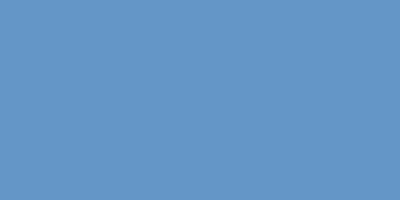

In [22]:
display(img) 

In [24]:
!pip install tabula-py

In [27]:
import tabula
tables = tabula.read_pdf("sample.pdf")
print(tables)

'pages' argument isn't specified.Will extract only from page 1 by default.


[     Name  Age         Job
0    Mike   28  Programmer
1  Olivia   38  Accountant
2     Bob   68  Accountant
3  Sophia   24      Lawyer
4   Simon   25  Programmer]


In [29]:
df = tables[0]
print(df[df.Age > 30])

     Name  Age         Job
1  Olivia   38  Accountant
2     Bob   68  Accountant
